# SOB4ES - Modelo XGBoost
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo de inteligencia artificial.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. **Configuracion:** Importaciones y parametros globales.
2. **Carga de datos:** Se cargan los tres splits pre-generados.
3. **Tuning:** Busqueda aleatoria de la mejor combinacion de hiperparametros.
4. **Validacion cruzada:** Evaluacion de robustez mediante repeticion de pliegues.
5. **Explicabilidad (SHAP):** Analisis de importancia de variables.
6. **Produccion:** Entrenamiento del ensamble final y exportacion de modelos.
7. **Evaluacion final:** Medicion del rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno
Importaciones y configuracion de rutas y variables globales.

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import itertools

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

import shap
import xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, KFold

# ignoramos los warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/xgb'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path('outputs/var').mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    #'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)


Librerias y variables cargadas correctamente...


In [2]:

# Deteccion de GPU / CUDA

# Comprueba si hay una GPU NVIDIA disponible y, en ese caso, configura
# XGBoost para usarla automaticamente. Si no hay GPU (o XGBoost no fue
# compilado con soporte CUDA), se usa la CPU sin que falle nada.

import subprocess

def _detectar_cuda():
    """Comprueba si hay una GPU NVIDIA con drivers CUDA disponibles en el sistema."""
    try:
        resultado = subprocess.run(
            ['nvidia-smi'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            timeout=5,
        )
        return resultado.returncode == 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return False

def _xgb_soporta_device():
    """XGBoost >= 2.0 usa el parametro 'device'; las versiones anteriores
    activan la GPU unicamente con tree_method='gpu_hist'."""
    try:
        return int(xgboost.__version__.split('.')[0]) >= 2
    except Exception:
        return False

CUDA_DISPONIBLE = _detectar_cuda()

if CUDA_DISPONIBLE and _xgb_soporta_device():
    # XGBoost >= 2.0: GPU via tree_method='hist' + device='cuda'
    XGB_DEVICE_PARAMS = {'tree_method': 'hist', 'device': 'cuda'}
elif CUDA_DISPONIBLE:
    # XGBoost < 2.0: GPU via tree_method='gpu_hist'
    XGB_DEVICE_PARAMS = {'tree_method': 'gpu_hist'}
else:
    XGB_DEVICE_PARAMS = {'tree_method': 'hist'}

print(f'GPU NVIDIA / CUDA detectada : {CUDA_DISPONIBLE}')
print(f'Version de XGBoost          : {xgboost.__version__}')
print(f'Parametros de dispositivo   : {XGB_DEVICE_PARAMS}')
if CUDA_DISPONIBLE:
    print('XGBoost usará la GPU para el tuning, la validacion y el entrenamiento de produccion...')
else:
    print('No se detecto GPU. XGBoost usara CPU (tree_method=\'hist\')...')

# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)
import os

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')


GPU NVIDIA / CUDA detectada : True
Version de XGBoost          : 3.3.0
Parametros de dispositivo   : {'tree_method': 'hist', 'device': 'cuda'}
XGBoost usará la GPU para el tuning, la validacion y el entrenamiento de produccion...
Nucleos disponibles: 20 | n_jobs asignado: 15


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 33)  |  X_test: (64, 33)  |  X_eval: (65, 33)


## 3.- Busqueda de hiperparametros (Tuning)

Se realiza una busqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparametros del modelo XGBoost. La busqueda se ejecuta exclusivamente sobre `X_train` para evitar cualquier fuga de informacion hacia los splits de validacion y evaluacion.

Como variable objetivo de referencia se usa `earthworm_shannon_z` (lombrices de tierra).


Para combatir el sobreajuste observado (Train R2 ~0.99, Val R2 ~0.47) se aplican tres medidas:
- Grid mas conservador: `max_depth` maximo 4, `n_estimators` maximo 300.
- Regularizacion L1/L2: se añaden `reg_alpha` y `reg_lambda` al grid.
- Early stopping: el entrenamiento para cuando el rendimiento en `X_test` deja de mejorar durante 20 iteraciones consecutivas.


Iniciando busqueda de hiperparametros (Tuning) para cada target...
Este proceso puede tardar bastante...

  [ 1/21] nematode_shannon_z             R2 CV: 0.1551 | Tiempo:  46.0s
  [ 2/21] macro_shannon_z                R2 CV: 0.1943 | Tiempo:  43.4s
  [ 3/21] earthworm_shannon_z            R2 CV: 0.4286 | Tiempo:  45.3s
  [ 4/21] orib_shannon_z                 R2 CV: 0.0790 | Tiempo:  43.5s
  [ 5/21] meso_shannon_z                 R2 CV: 0.0967 | Tiempo:  43.5s
  [ 6/21] coll_shannon_z                 R2 CV: 0.2097 | Tiempo:  44.7s
  [ 7/21] bac_shannon_z                  R2 CV: 0.0854 | Tiempo:  42.8s
  [ 8/21] fun_shannon_z                  R2 CV: -0.0096 | Tiempo:  42.5s
  [ 9/21] euk_shannon_z                  R2 CV: 0.1560 | Tiempo:  43.1s
  [10/21] oomy_shannon_z                 R2 CV: 0.1373 | Tiempo:  44.0s
  [11/21] cerc_shannon_z                 R2 CV: 0.0197 | Tiempo:  42.7s
  [12/21] macro_order_richness_z         R2 CV: 0.2054 | Tiempo:  43.4s
  [13/21] earthworm_richness_

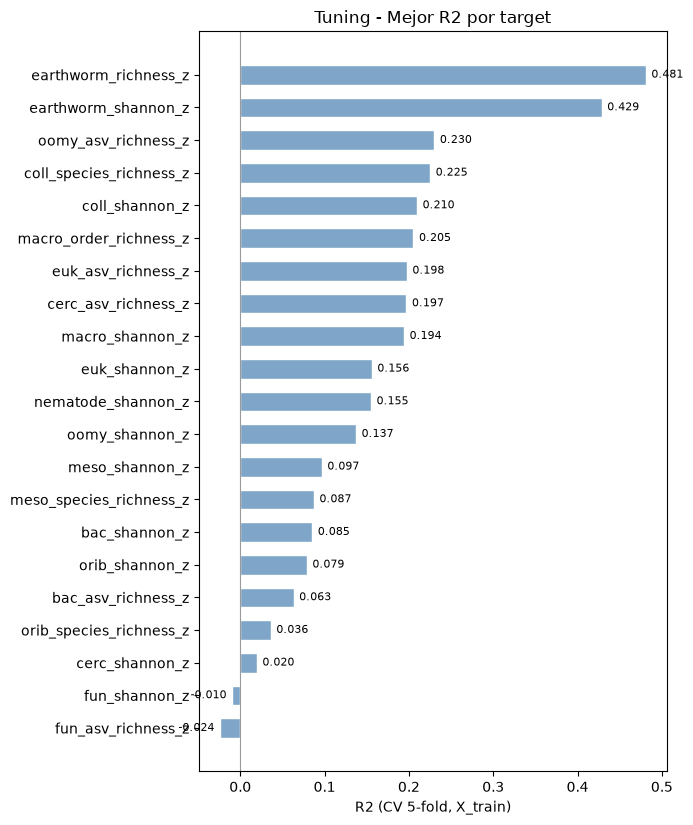

In [4]:
print("Iniciando busqueda de hiperparametros (Tuning) para cada target...")
print("Este proceso puede tardar bastante...\n")

param_grid = {
	'n_estimators':     [50, 100, 150],
	'max_depth':        [2, 3],
	'learning_rate':    [0.01, 0.05],
	'subsample':        [0.4, 0.5, 0.6],
	'colsample_bytree': [0.3, 0.4, 0.5],
	'gamma':            [1.0, 5.0, 10.0],
	'min_child_weight': [10, 20, 30],
	'reg_alpha':        [5.0, 10.0, 20.0],
	'reg_lambda':       [10.0, 20.0, 50.0],
	'grow_policy':      ['depthwise'],
	'tree_method':      [XGB_DEVICE_PARAMS['tree_method']],
	'random_state':     [42],
}

if 'device' in XGB_DEVICE_PARAMS:
    param_grid['device'] = [XGB_DEVICE_PARAMS['device']]

XGB_OPTIMAL_PARAMS_PER_TARGET = {}
resultados_tuning = {}
global_start = time.time()

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y_prueba = y_train[target_col].values

    buscador = RandomizedSearchCV(
        estimator=XGBRegressor(**XGB_DEVICE_PARAMS, random_state=42),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2',
        cv=5,
        verbose=0,
        random_state=42,
        n_jobs=N_JOBS
    )
    buscador.fit(X_train, y_prueba)

    params_target = dict(buscador.best_params_)
    params_target.update(XGB_DEVICE_PARAMS)
    params_target['random_state'] = 42

    XGB_OPTIMAL_PARAMS_PER_TARGET[target_col] = params_target
    resultados_tuning[target_col] = {'params': params_target, 'r2': buscador.best_score_}

    print(f"  [{idx:2d}/{len(TARGETS)}] {target_col:30} R2 CV: {buscador.best_score_:.4f} | Tiempo: {time.time()-t0:>5.1f}s")

print(f"\nTuning por target completado en {(time.time() - global_start) / 60:.1f} minutos.\n")

# Grafico: R2 de tuning por target (ordenado)
_tuning_r2 = {t: resultados_tuning[t]['r2'] for t in TARGETS}
_orden = sorted(_tuning_r2, key=_tuning_r2.get)
fig, ax = plt.subplots(figsize=(7, 0.35 * len(_orden) + 1))
_bars = ax.barh([t for t in _orden], [_tuning_r2[t] for t in _orden], color=PALETTE['blue'], edgecolor='white', height=0.6)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4.- Validacion cruzada

Se evalua la robustez del modelo mediante validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) aplicada sobre `X_train`. Esto permite detectar sobreajuste comparando el rendimiento en entrenamiento y en los pliegues de validacion.

In [5]:
from sklearn.model_selection import RepeatedKFold

print('Validacion cruzada repetida (15 evaluaciones sobre X_train, por target)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

print(f"{'TARGET':<25} | {'TRAIN R2':<10} | {'CV R2':<10} | {'DIFF':<10} | {'ESTADO'}")
print("-" * 75)

for nombre_target in TARGETS:
    y_prueba = y_train[nombre_target].values
    modelo_evaluacion = XGBRegressor(**XGB_OPTIMAL_PARAMS_PER_TARGET[nombre_target])

    resultados_examen = cross_validate(
        estimator=modelo_evaluacion,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True
    )

    r2_entrenamiento = np.mean(resultados_examen['train_r2'])
    r2_examen_real   = np.mean(resultados_examen['test_r2'])
    diferencia       = r2_entrenamiento - r2_examen_real

    estado = 'Aviso: Posible sobreajuste' if diferencia > 0.15 else 'OK'

    print(f"{nombre_target:<25} | {r2_entrenamiento:<10.3f} | {r2_examen_real:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida (15 evaluaciones sobre X_train, por target)...

TARGET                    | TRAIN R2   | CV R2      | DIFF       | ESTADO
---------------------------------------------------------------------------
nematode_shannon_z        | 0.394      | 0.181      | 0.213      | Aviso: Posible sobreajuste
macro_shannon_z           | 0.405      | 0.195      | 0.210      | Aviso: Posible sobreajuste
earthworm_shannon_z       | 0.583      | 0.391      | 0.193      | Aviso: Posible sobreajuste
orib_shannon_z            | 0.309      | 0.081      | 0.228      | Aviso: Posible sobreajuste
meso_shannon_z            | 0.311      | 0.099      | 0.212      | Aviso: Posible sobreajuste
coll_shannon_z            | 0.431      | 0.169      | 0.263      | Aviso: Posible sobreajuste
bac_shannon_z             | 0.266      | 0.020      | 0.246      | Aviso: Posible sobreajuste
fun_shannon_z             | 0.099      | -0.006     | 0.105      | OK
euk_shannon_z             | 0.362      | 0.141

## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (SHapley Additive exPlanations) para identificar que variables influyen mas en las predicciones del modelo y en que direccion lo hacen.

El grafico de puntos muestra las 10 variables mas importantes:
- Las variables se ordenan de mayor a menor importancia global (de arriba a abajo).
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posicion horizontal indica el efecto sobre la prediccion (derecha = aumenta el indice, izquierda = lo reduce).

Calculando valores SHAP sobre X_train...
Top 10 variables por importancia SHAP (earthworm_shannon_z):


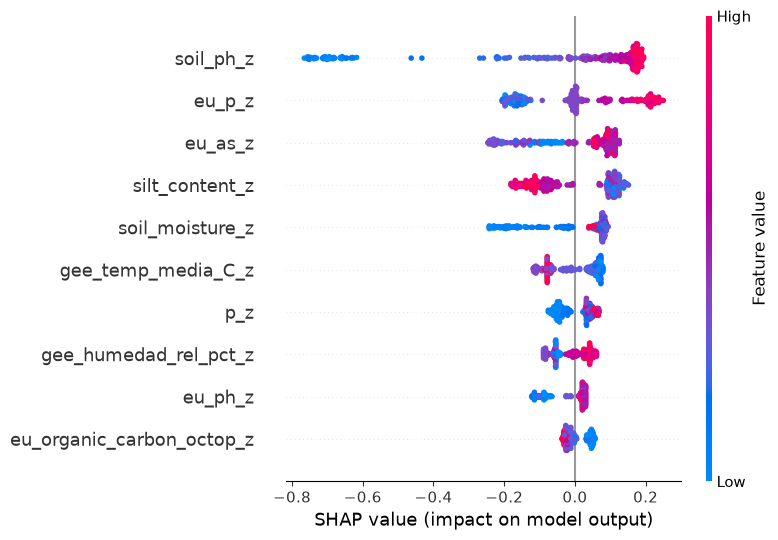

Top 10 variables por importancia SHAP (earthworm_richness_z):


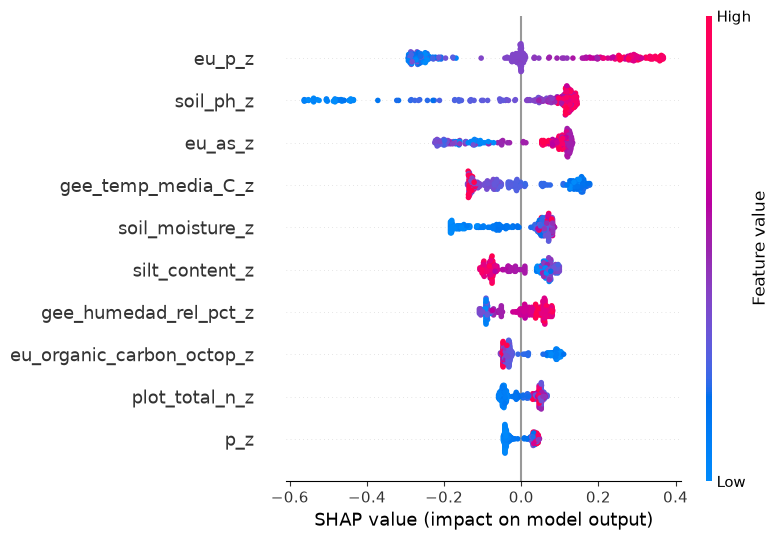

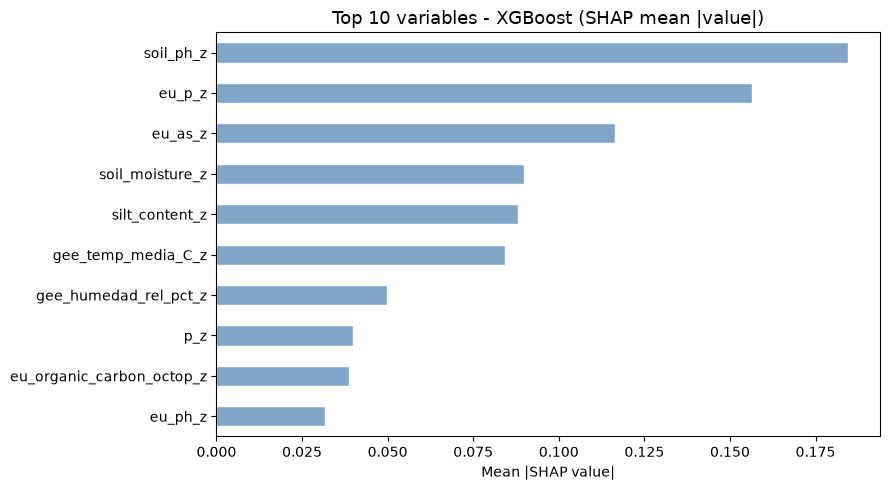


Datos exportados correctamente para revisión en: 'output/var/variables_mas_relevantes_xgboost.csv'


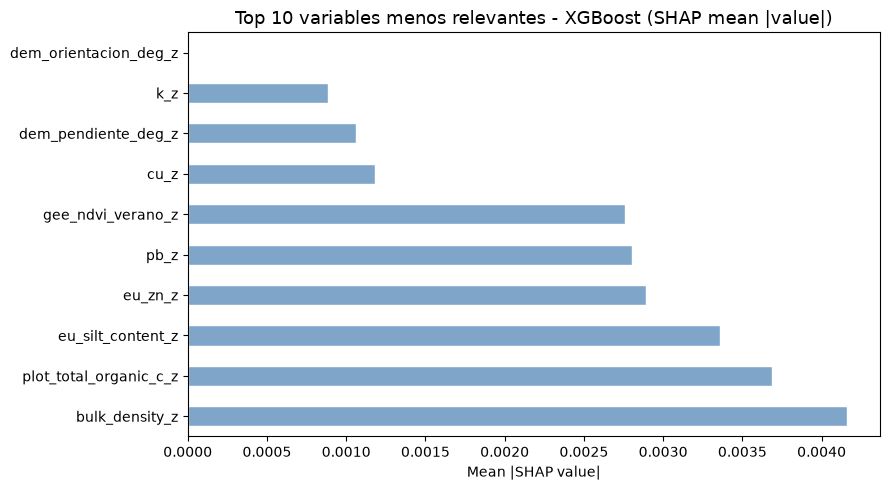


Datos exportados correctamente para revisión en: 'output/var/variables_menos_relevantes_xgboost.csv'


In [6]:
%matplotlib inline

print("Calculando valores SHAP sobre X_train...")

# Shannon

modelo_explicable_shannon = XGBRegressor(**XGB_OPTIMAL_PARAMS_PER_TARGET['earthworm_shannon_z'])
modelo_explicable_shannon.fit(X_train, y_train['earthworm_shannon_z'].values)

explainer_shannon   = shap.TreeExplainer(modelo_explicable_shannon)
shap_values_shannon = explainer_shannon.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_shannon_z):")
shap.summary_plot(shap_values_shannon, X_train, plot_type="dot", max_display=10)

# Richness
modelo_explicable_richness = XGBRegressor(**XGB_OPTIMAL_PARAMS_PER_TARGET['earthworm_richness_z'])
modelo_explicable_richness.fit(X_train, y_train['earthworm_richness_z'].values)

explainer_richness   = shap.TreeExplainer(modelo_explicable_richness)
shap_values_richness = explainer_richness.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_richness_z):")
shap.summary_plot(shap_values_richness, X_train, plot_type="dot", max_display=10)
# Grafico: barplot importancia SHAP media (shannon + richness)
shap_mean = np.mean([
    np.abs(shap_values_shannon),
    np.abs(shap_values_richness)
], axis=0).mean(axis=0)

shap_importance = pd.Series(shap_mean, index=FEATURES_AUTORIZADAS).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables - XGBoost (SHAP mean |value|)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

# Exportación
csv_path = 'output/var/variables_mas_relevantes_xgboost.csv'
shap_importance.rename_axis('variable').reset_index(name='importancia').to_csv(csv_path, index=False)
print(f"\nDatos exportados correctamente para revisión en: '{csv_path}'")

# Grafico: barplot variables menos relevantes (SHAP mean |value|)
shap_importance_bottom = pd.Series(shap_mean, index=FEATURES_AUTORIZADAS).nsmallest(10).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance_bottom.plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables menos relevantes - XGBoost (SHAP mean |value|)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

# Exportación
csv_path = 'output/var/variables_menos_relevantes_xgboost.csv'
shap_importance_bottom.rename_axis('variable').reset_index(name='importancia').to_csv(csv_path, index=False)
print(f"\nDatos exportados correctamente para revisión en: '{csv_path}'")

## 6.- Entrenamiento de produccion

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria en cada uno. Esto reduce la varianza de las predicciones y mejora la robustez en produccion.

Todos los modelos se entrenan sobre `X_train` y se guardan en disco en formato `.pkl`.

In [7]:
print("Entrenamiento de produccion (ensamble de 5 modelos por target)...")
print("-" * 70)

global_start_time = time.time()
NUM_EXPERTOS = 5

for idx, target_col in enumerate(TARGETS, 1):
    target_start_time = time.time()
    y = y_train[target_col].values

    for experto_id in range(NUM_EXPERTOS):
        parametros_experto = XGB_OPTIMAL_PARAMS_PER_TARGET[target_col].copy()
        parametros_experto['random_state'] = 42 + experto_id

        model = XGBRegressor(**parametros_experto)
        model.fit(X_train, y)

        pkl_path = os.path.join(MODELS_DIR, f"xgb_prod_{target_col}_exp{experto_id}.pkl")
        joblib.dump(model, pkl_path)

    elapsed = time.time() - target_start_time
    print(f"  [{idx}/{len(TARGETS)}] {target_col:30} completado ({elapsed:.1f}s)")

print("-" * 70)
print(f"Produccion completada en {(time.time() - global_start_time)/60:.1f} minutos.")
print(f"Modelos guardados: {len(TARGETS) * NUM_EXPERTOS} ({NUM_EXPERTOS} por target).")

Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------
  [1/21] nematode_shannon_z             completado (0.3s)
  [2/21] macro_shannon_z                completado (0.3s)
  [3/21] earthworm_shannon_z            completado (0.3s)
  [4/21] orib_shannon_z                 completado (0.3s)
  [5/21] meso_shannon_z                 completado (0.3s)
  [6/21] coll_shannon_z                 completado (0.3s)
  [7/21] bac_shannon_z                  completado (0.3s)
  [8/21] fun_shannon_z                  completado (0.2s)
  [9/21] euk_shannon_z                  completado (0.3s)
  [10/21] oomy_shannon_z                 completado (0.3s)
  [11/21] cerc_shannon_z                 completado (0.2s)
  [12/21] macro_order_richness_z         completado (0.2s)
  [13/21] earthworm_richness_z           completado (0.3s)
  [14/21] orib_species_richness_z        completado (0.2s)
  [15/21] meso_species_richness_z        compl

## 7.- Evaluacion final sobre eval.csv

Por primera vez se usa `eval.csv`: el dataset que el modelo no ha visto en ningun momento anterior. Esto proporciona una estimacion real e imparcial del rendimiento en produccion.

Ademas se ejecuta una comprobacion de funcionamiento completo del pipeline (smoke test): se carga el ensamble desde disco, se predice sobre datos nuevos y se verifica que la inferencia por consenso funciona correctamente.

**Interpretacion del indice Shannon H':**  
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica). Un valor bajo indica un suelo poco diverso; un valor alto, un suelo biologicamente rico.

Evaluacion final sobre eval.csv
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z               0.1692   0.9001   0.7136
  macro_shannon_z                  0.2668   0.8600   0.7355
  earthworm_shannon_z              0.4935   0.7104   0.5325
  orib_shannon_z                   0.1447   1.0576   0.8927
  meso_shannon_z                  -0.2089   1.0738   0.8844
  coll_shannon_z                  -0.3073   0.7243   0.5873
  bac_shannon_z                    0.0113   0.9957   0.6660
  fun_shannon_z                   -0.0139   1.1520   0.9306
  euk_shannon_z                    0.1048   0.9176   0.6536
  oomy_shannon_z                   0.0924   0.9959   0.7409
  cerc_shannon_z                  -0.0341   0.9106   0.6300
  macro_order_richness_z           0.3047   0.7636   0.6455
  earthworm_richness_z             0.5118   0.6380   0.4

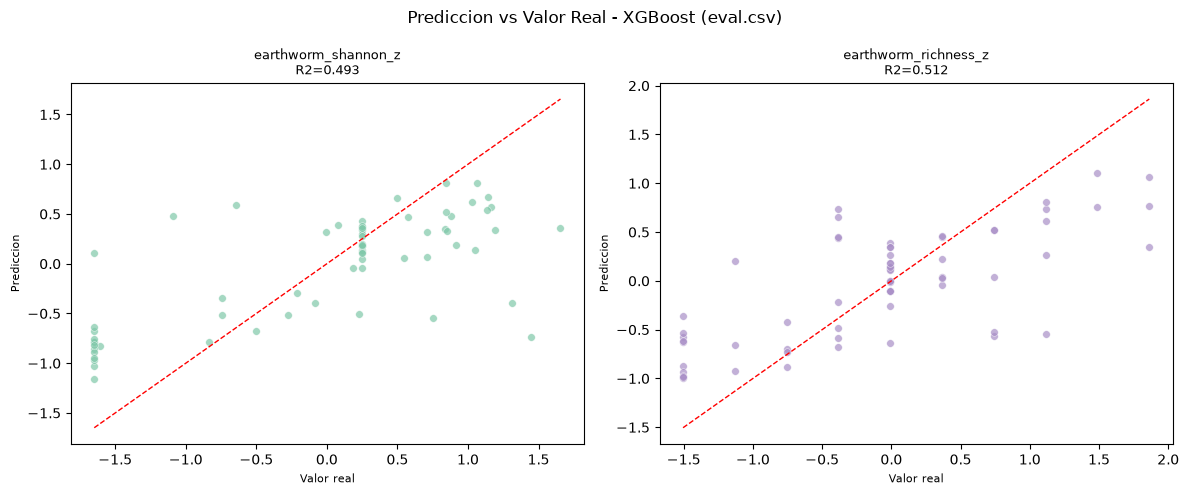

In [8]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

NUM_EXPERTOS = 5

# Evaluacion final sobre todos los targets
# Usamos eval.csv, que el modelo no ha visto hasta ahora.

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    # Cargamos los 5 modelos del target actual y promediamos sus predicciones
    preds_eval = []
    for experto_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
        model = joblib.load(ruta)
        preds_eval.append(model.predict(X_eval))

    y_pred_eval = np.mean(preds_eval, axis=0)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)


# Smoke test con datos reales
# Se prueba sobre dos targets representativos: uno shannon y uno richness.

print('Smoke test - Inferencia con datos reales')
print('-' * 65)

try:
    # Tomamos 3 filas reales al azar del dataset de evaluacion
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)

        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        # Cada uno de los 5 modelos vota con su propia prediccion para las 3 parcelas
        votos = []
        for experto_id in range(NUM_EXPERTOS):
            ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
            m     = joblib.load(ruta)
            pred  = m.predict(df_new_data)
            votos.append(pred)
            print(f'  Modelo {experto_id+1} -> '
                  f'Fila {indices_elegidos[0]}: {pred[0]:.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred[1]:.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred[2]:.4f}')

        # Promediamos los 5 votos para obtener la prediccion final de consenso
        consenso = np.mean(votos, axis=0)

        print('  ' + '-' * 63)
        print('  Resultados detallados por muestra evaluada:')
        print('  ' + '-' * 63)

        for i, idx_muestra in enumerate(indices_elegidos):
            pred_val = consenso[i]
            real_val = valores_reales[i]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx_muestra:<4} | Prediccion: {pred_val:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('\nSmoke test superado. El pipeline de XGBoost funciona y predice con coherencia.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    preds = []
    for experto_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{tgt}_exp{experto_id}.pkl')
        preds.append(joblib.load(ruta).predict(X_eval))
    yp = np.mean(preds, axis=0)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - XGBoost (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()